In [1]:
import pandas as pd
import numpy as np

In [2]:
df =pd.read_csv('../data/IMDB Dataset.csv')

In [3]:
df.head()
df.shape

(50000, 2)

In [4]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [5]:
df['sentiment']=df['sentiment'].map({'positive':1,'negative':0})

In [6]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [7]:
X = df['review']
y = df['sentiment']

In [8]:
import re
import string

In [9]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [10]:
df['cleaned_review'] = df['review'].apply(clean_text)

In [11]:
df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...


In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

"""Parameters
vocab this is the number of unique words we want to keep in our tokenizer
max_length this is the maximum length of the sequences we want to create. 
If a review has more words than this, it will be truncated. 
If it has fewer words, it will be padded.
oov_token this is the token that will be used to 
represent words that are not in the vocabulary."""

In [13]:



VOCAB_SIZE = 10000
MAX_LENGTH = 200
OOV_TOKEN = "<OOV>"

In [14]:
# Create the tokenizer and fit it on the cleaned reviews
tokenizer=Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df['cleaned_review'])

In [15]:
# Convert the cleaned reviews to sequences of integers
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])


In [16]:
# pad the sequences to ensure they are all the same length
padded_sequences = pad_sequences(
    sequences, 
    maxlen=MAX_LENGTH, 
    padding='post', 
    truncating='post'
)

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, 
    df['sentiment'], 
    test_size=0.2, 
    random_state=42
)

In [18]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40000, 200), (10000, 200), (40000,), (10000,))

In [19]:
with open("../tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer, f)

# STEP 4 — Build LSTM Model

In [20]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [38]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(MAX_LENGTH,)),
    
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),
    
    tf.keras.layers.LSTM(64),
    
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [39]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5251 - loss: 0.6884

500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 117ms/step - accuracy: 0.5455 - loss: 0.6832 - val_accuracy: 0.4130 - val_loss: 0.7763 - learning_rate: 0.0010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5603 - loss: 0.6752

500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 118ms/step - accuracy: 0.5964 - loss: 0.6553 - val_accuracy: 0.6846 - val_loss: 0.6344 - learning_rate: 0.0010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.6212 - loss: 0.6388 - val_accuracy: 0.5347 - val_loss: 0.6924 - learning_rate: 0.0010
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6620 - loss: 0.5986

500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 109ms/step - accuracy: 0.6884 - loss: 0.5879 - val_accuracy: 0.6944 - val_loss: 0.6197 - learning_rate: 0.0010
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8113 - loss: 0.4363

500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.8454 - loss: 0.3712 - val_accuracy: 0.8491 - val_loss: 0.3629 - learning_rate: 0.0010
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9050 - loss: 0.2510

500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 113ms/step - accuracy: 0.9019 - loss: 0.2515 - val_accuracy: 0.8536 - val_loss: 0.3469 - learning_rate: 0.0010
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 110ms/step - accuracy: 0.9291 - loss: 0.1960 - val_accuracy: 0.8562 - val_loss: 0.3714 - learning_rate: 0.0010
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 111ms/step - accuracy: 0.9496 - loss: 0.1519 - val_accuracy: 0.8506 - val_loss: 0.4097 - learning_rate: 0.0010
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9673 - loss: 0.1122
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 111ms/step - accuracy: 0.9654 - loss: 0.1151 - val_accuracy: 0.8466 - val_loss: 0.4673 - learning_rate: 0.0010
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 111ms/step - accuracy: 0.9793 - loss: 0.0791 - val_accuracy: 0.8499 - val_loss: 0.5033 - learning_rate: 5.0000e-04
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 113ms/step - accuracy: 0.9860 - l

In [42]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8615 - loss: 0.3372
Test Accuracy: 0.8615000247955322


In [43]:
model.save("final_lstm_model.keras")

In [44]:
# Evaluate the model on the test set
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred_probs = model.predict(X_test)
preds = (pred_probs > 0.5).astype(int)

print(classification_report(y_test, preds))

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4961
           1       0.85      0.88      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [45]:
confusion_matrix(y_test, preds)


array([[4204,  757],
       [ 628, 4411]])

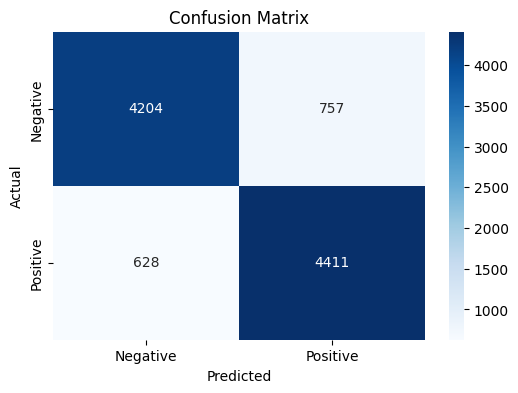

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [47]:
def predict_review(text):
    
    text = clean_text(text)
    
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH)
    
    prob = model.predict(padded)[0][0]
    
    if prob > 0.5:
        return "Positive Review"
    else:
        return "Negative Review"

In [48]:
predict_review("This movie was absolutely fantastic")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


'Positive Review'